# PRCP-1017: Automobile Price Prediction

**Internship / Final Year Project**  
**Student:** Gopala Krishna Avula  
**Project Code:** PRCP-1017-AutoPricePred  

---

## Aim of the Project
The aim of this project is to study the auto imports dataset and build a machine learning model that can predict the **price of a car** using its different features like engine size, horsepower, body style, fuel type, etc.

This kind of model can help management understand:
- which features affect car price the most
- how prices change when design or specs change
- pricing strategy for a new market

---

## Tasks Completed in this Notebook
1. **Data Analysis Report** – cleaning, EDA, and insights from the data  
2. **Predictive Modeling** – build models to predict car price  
3. **Model Comparison Report** – compare models and choose the best one  
4. **Challenges Faced** – problems in data and how I solved them  

> Note: As per project guidelines, all tasks are done in this single Jupyter notebook for final submission.


## 1. Importing Required Libraries

I used common Python libraries that we study in data science:
- `pandas` and `numpy` for data handling
- `matplotlib` and `seaborn` for graphs
- `scikit-learn` for preprocessing and ML models


In [1]:
%matplotlib inline

# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For nicer looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully!')


Libraries imported successfully!


## 2. Loading the Dataset

The CSV file does **not** contain column names, so I added them based on the attribute information given in the project document and `auto_imports_names.txt`.

Missing values in this dataset are marked as `?`.


In [2]:
# Column names as per attribute information
columns = [
    'symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
    'num_of_doors', 'body_style', 'drive_wheels', 'engine_location',
    'wheel_base', 'length', 'width', 'height', 'curb_weight',
    'engine_type', 'num_of_cylinders', 'engine_size', 'fuel_system',
    'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm',
    'city_mpg', 'highway_mpg', 'price'
]

# Load data. na_values='?' makes pandas treat ? as missing
df = pd.read_csv('auto_imports.csv', header=None, names=columns, na_values='?')

print('Dataset shape:', df.shape)
df.head()


Dataset shape: (201, 26)


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


## 3. Basic Information about the Data

First I checked the shape, data types, missing values and summary statistics. This helps to understand what cleaning is needed.


In [3]:
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])
print()
df.info()


Number of rows: 201
Number of columns: 26

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               201 non-null    str    
 3   fuel_type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num_of_doors       199 non-null    str    
 6   body_style         201 non-null    str    
 7   drive_wheels       201 non-null    str    
 8   engine_location    201 non-null    str    
 9   wheel_base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb_weight        201 non-null    int64  
 14  engine_type        201 non-null    str    
 15  num_of_cylinders   201 non-null    str    

In [4]:
# Statistical summary for numerical columns
df.describe()


,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,201.000000,164.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000
mean,0.840796,122.000000,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,35.442168,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


In [5]:
# Check how many missing values are in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print('Columns with missing values:')
missing_df


Columns with missing values:


,Missing Count,Missing %
normalized_losses,37,18.41
bore,4,1.99
stroke,4,1.99
num_of_doors,2,1.00
horsepower,2,1.00
peak_rpm,2,1.00


### Observation – Missing Values
From the above table we can see:
- `normalized_losses` has the highest missing values (around 20%)
- `price` also has some missing values (target column)
- Other columns like `bore`, `stroke`, `horsepower`, `peak_rpm`, `num_of_doors` have few missing values

Since `price` is our target, I will **drop rows where price is missing**, because training without target value is not useful.


## 4. Data Cleaning

### Steps I followed:
1. Drop rows where `price` is missing  
2. Convert related object columns that are actually numbers into numeric type  
3. Fill remaining missing values using mean/median/mode  
4. Convert word numbers like "four", "six" into actual numbers where needed  


In [6]:
# Make a working copy so original data is safe
data = df.copy()

# Drop rows with missing price (target variable)
print('Rows before dropping missing price:', data.shape[0])
data = data.dropna(subset=['price']).reset_index(drop=True)
print('Rows after dropping missing price:', data.shape[0])


Rows before dropping missing price: 201
Rows after dropping missing price: 201


In [7]:
# Convert numerical-looking columns to float
num_cols_to_convert = [
    'normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm', 'price'
]
for col in num_cols_to_convert:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print(data.dtypes)


symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_of_doors             str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_of_cylinders         str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                  int64
dtype: object


In [8]:
# Convert cylinder and door words to numbers (helps the model)
cylinder_map = {
    'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'eight': 8, 'twelve': 12
}
door_map = {'two': 2, 'four': 4}

data['num_of_cylinders'] = data['num_of_cylinders'].map(cylinder_map)
data['num_of_doors'] = data['num_of_doors'].map(door_map)

# Fill num_of_doors missing with mode
data['num_of_doors'] = data['num_of_doors'].fillna(data['num_of_doors'].mode()[0])

print(data[['num_of_cylinders', 'num_of_doors']].head())


   num_of_cylinders  num_of_doors
0                 4           2.0
1                 4           2.0
2                 6           2.0
3                 4           4.0
4                 5           4.0


In [9]:
# Fill missing numerical values with median (safer than mean if outliers exist)
num_fill_cols = ['normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm']
for col in num_fill_cols:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val)
    print(f'{col}: filled missing with median = {median_val}')

print()
print('Remaining missing values:', data.isnull().sum().sum())


normalized_losses: filled missing with median = 115.0
bore: filled missing with median = 3.31
stroke: filled missing with median = 3.29
horsepower: filled missing with median = 95.0
peak_rpm: filled missing with median = 5200.0

Remaining missing values: 0


## 5. Exploratory Data Analysis (EDA) – Data Analysis Report

In this section I tried to understand the distribution of price and how different features relate to price.


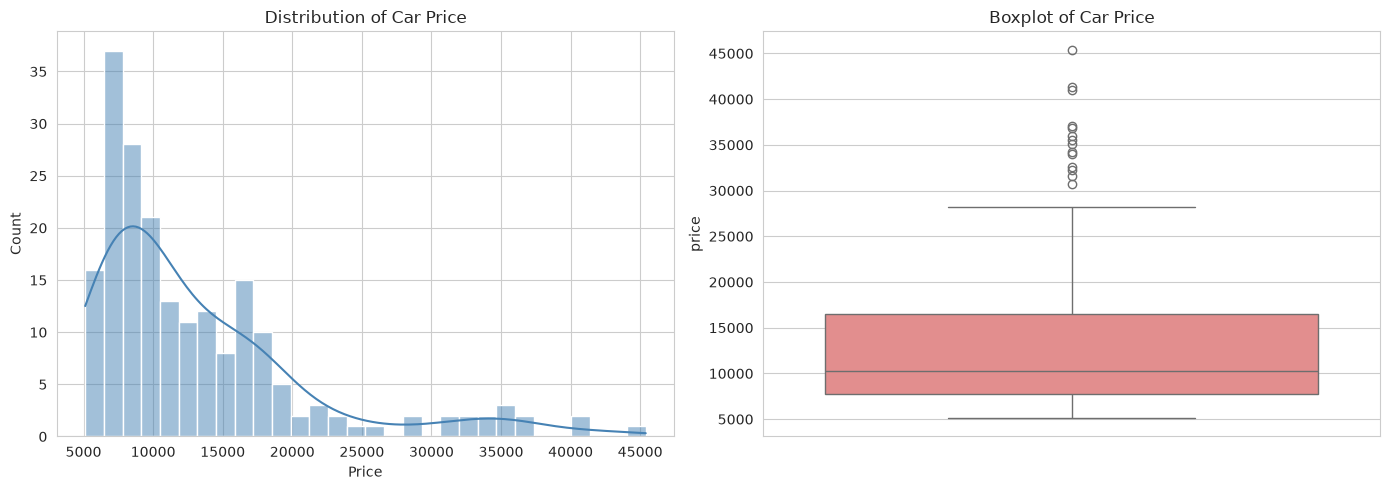

Mean price: 13207.13
Median price: 10295.0
Min price: 5118
Max price: 45400


In [10]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['price'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Car Price')
axes[0].set_xlabel('Price')

sns.boxplot(y=data['price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Car Price')

plt.tight_layout()
plt.show()

print('Mean price:', round(data['price'].mean(), 2))
print('Median price:', round(data['price'].median(), 2))
print('Min price:', data['price'].min())
print('Max price:', data['price'].max())


### Observation – Price Distribution
- Most cars are in the lower to mid price range.
- Mean is higher than median, which means the distribution is **right-skewed** (some expensive luxury cars pull the average up).
- There are some high-price outliers (luxury brands).


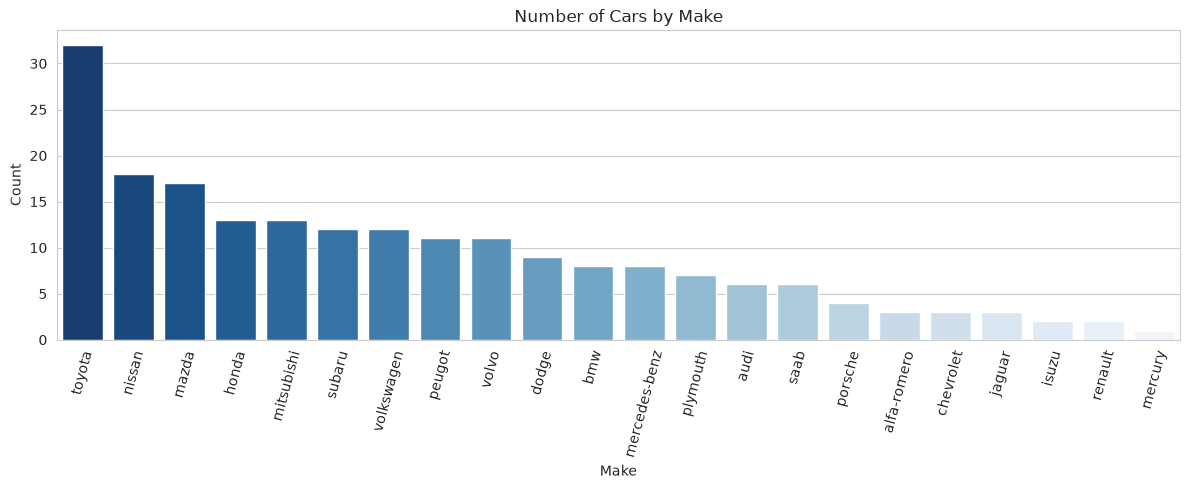

In [11]:
# Number of cars by make (brand)
plt.figure(figsize=(12, 5))
order = data['make'].value_counts().index
sns.countplot(data=data, x='make', order=order, palette='Blues_r')
plt.xticks(rotation=75)
plt.title('Number of Cars by Make')
plt.xlabel('Make')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


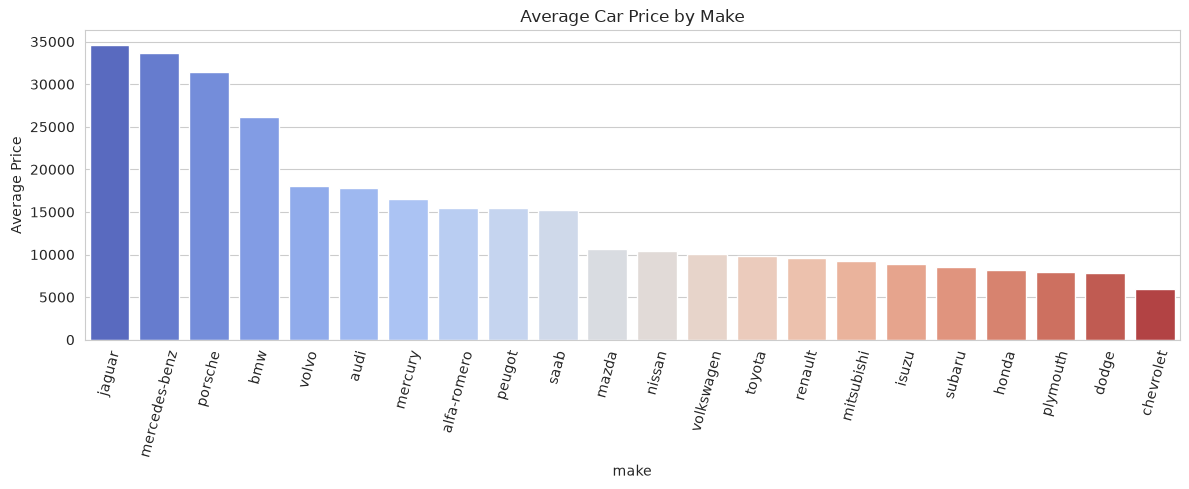

In [12]:
# Average price by make
plt.figure(figsize=(12, 5))
avg_price = data.groupby('make')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values, palette='coolwarm')
plt.xticks(rotation=75)
plt.title('Average Car Price by Make')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()


### Observation – Make vs Price
- Brands like **mercedes-benz, jaguar, porsche, bmw** have higher average prices.
- Brands like **chevrolet, dodge, plymouth** are on the cheaper side.
- So brand (`make`) is an important categorical feature for price prediction.


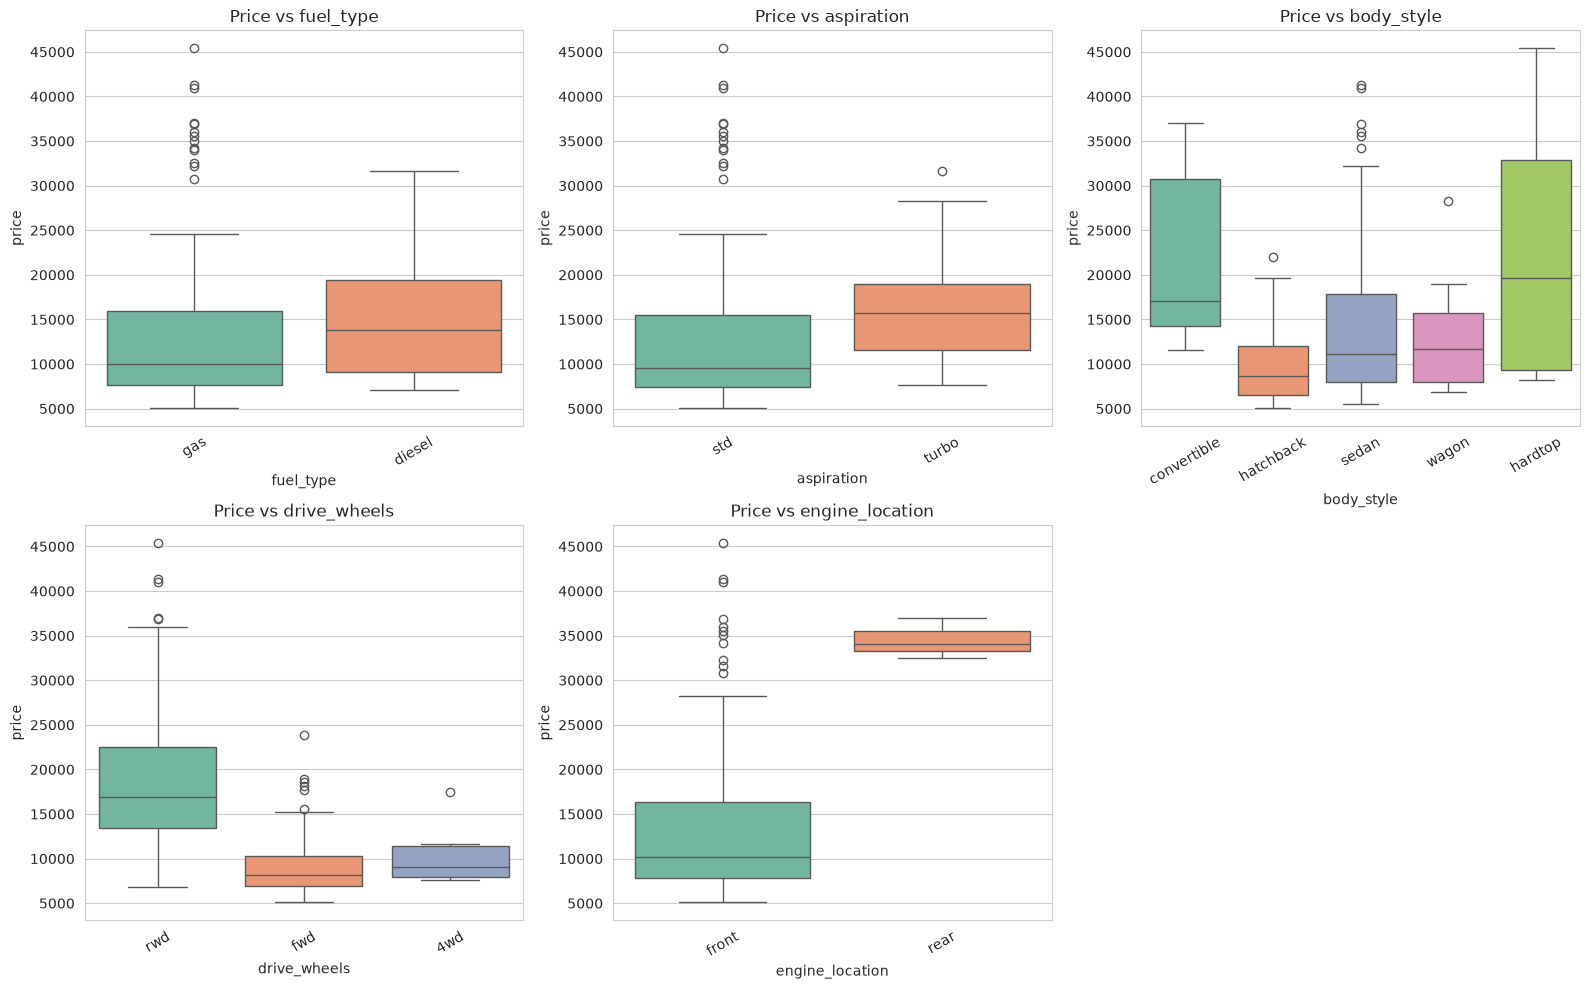

In [13]:
# Categorical features vs price
cat_features = ['fuel_type', 'aspiration', 'body_style', 'drive_wheels', 'engine_location']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.boxplot(data=data, x=col, y='price', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Price vs {col}')
    axes[i].tick_params(axis='x', rotation=30)

# hide unused subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()


### Observation – Categorical Features
- **Diesel** cars are generally a bit costlier than gas cars in this data.
- **Turbo** aspiration cars tend to cost more than standard.
- **Convertible / hardtop** styles look more expensive on average.
- **rwd** (rear wheel drive) cars are costlier than fwd.
- Cars with **rear engine location** have higher prices (mostly sports cars), but sample size is small.


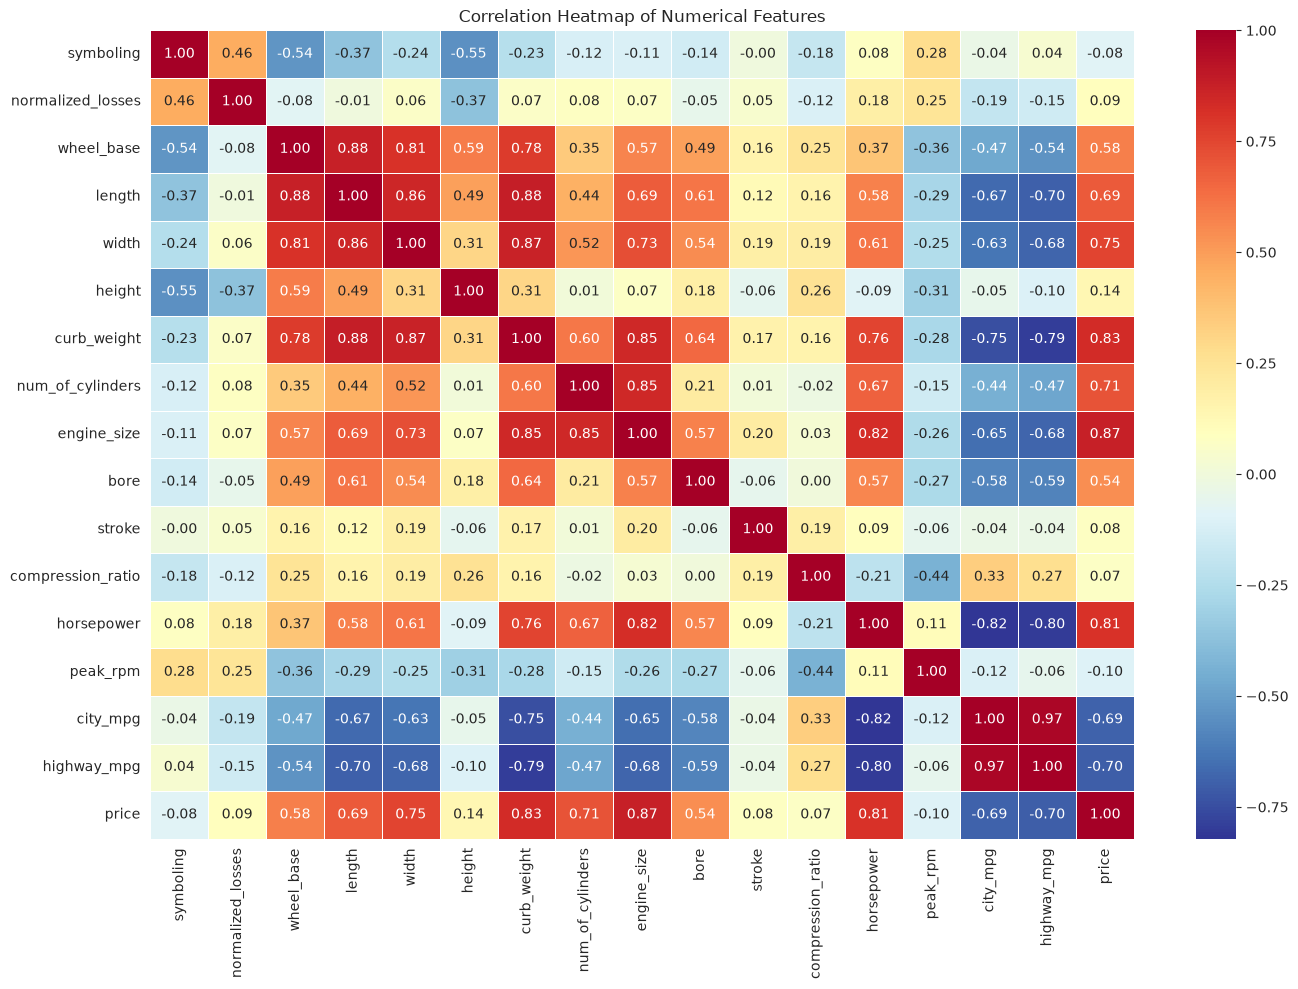

In [14]:
# Numerical features correlation with price
num_features = [
    'symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height',
    'curb_weight', 'num_of_cylinders', 'engine_size', 'bore', 'stroke',
    'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price'
]

corr = data[num_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


In [15]:
# Top correlations with price
price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
print('Correlation of features with Price:')
print(price_corr)


Correlation of features with Price:
engine_size          0.872335
curb_weight          0.834415
horsepower           0.810500
width                0.751265
num_of_cylinders     0.708645
highway_mpg         -0.704692
length               0.690628
city_mpg            -0.686571
wheel_base           0.584642
bore                 0.543158
height               0.135486
peak_rpm            -0.102310
normalized_losses    0.094366
symboling           -0.082391
stroke               0.082209
compression_ratio    0.071107
Name: price, dtype: float64


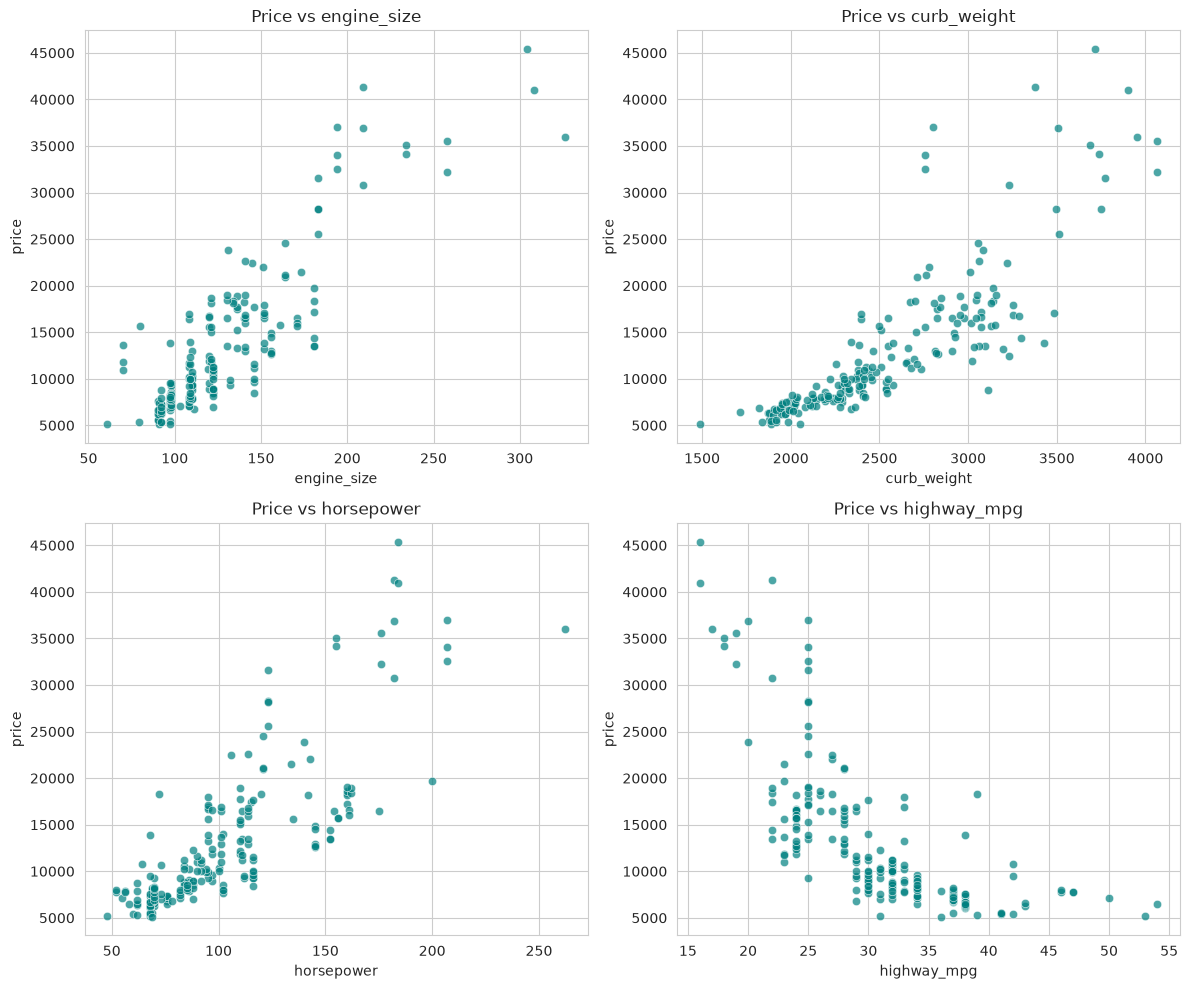

In [16]:
# Scatter plots for strongest related features
strong_features = ['engine_size', 'curb_weight', 'horsepower', 'highway_mpg']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(strong_features):
    sns.scatterplot(data=data, x=col, y='price', ax=axes[i], color='teal', alpha=0.7)
    axes[i].set_title(f'Price vs {col}')

plt.tight_layout()
plt.show()


### Observation – Numerical Features (EDA Summary)
From correlation and scatter plots:
- **Positive relation with price:** `engine_size`, `curb_weight`, `horsepower`, `width`, `length`, `num_of_cylinders`
- **Negative relation with price:** `city_mpg`, `highway_mpg` (more mileage → usually cheaper economy cars)
- `engine_size` and `curb_weight` look like the strongest predictors
- `city_mpg` and `highway_mpg` are highly correlated with each other (multicollinearity), which is expected

---

### EDA Final Insights
1. Price is right-skewed due to luxury cars.  
2. Brand and drive type clearly affect price.  
3. Bigger engines, heavier cars and higher horsepower → higher price.  
4. Higher mileage cars are generally cheaper.  
5. Missing values were manageable after dropping missing prices and filling other columns.


## 6. Feature Preparation for Machine Learning

Now I prepare the data for modeling:
- Separate features (X) and target (y)
- Encode categorical columns using Label Encoding (simple and enough for this project size)
- Split into train and test sets (80% train, 20% test)
- Scale numerical features for models that need scaling (like KNN, SVR)


In [17]:
# Create modeling dataframe
model_df = data.copy()

# Categorical columns to encode
cat_cols = [
    'make', 'fuel_type', 'aspiration', 'body_style',
    'drive_wheels', 'engine_location', 'engine_type', 'fuel_system'
]

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    label_encoders[col] = le

print('Categorical columns encoded.')
model_df.head()


Categorical columns encoded.


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,115.0,0,1,0,2.0,0,2,0,88.6,...,130,5,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,115.0,0,1,0,2.0,0,2,0,88.6,...,130,5,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,115.0,0,1,0,2.0,2,2,0,94.5,...,152,5,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,1,1,0,4.0,3,1,0,99.8,...,109,5,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,1,1,0,4.0,3,0,0,99.4,...,136,5,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [18]:
# Features and target
X = model_df.drop('price', axis=1)
y = model_df['price']

print('Feature shape:', X.shape)
print('Target shape:', y.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])


Feature shape: (201, 25)
Target shape: (201,)
Train size: 160
Test size: 41


In [19]:
# Scaling (mainly useful for KNN and SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For tree-based models we can use original values
print('Scaling done.')


Scaling done.


## 7. Building Predictive Models

I trained multiple regression models which are commonly used in academics:

1. Linear Regression  
2. Ridge Regression  
3. Lasso Regression  
4. Decision Tree Regressor  
5. Random Forest Regressor  
6. Gradient Boosting Regressor  
7. K-Nearest Neighbors (KNN)  
8. Support Vector Regressor (SVR)  

Then I compared them using **MAE, RMSE and R² score**.


In [20]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    '''Train model and return evaluation metrics'''
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    return {
        'Model': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 4),
        'y_pred': y_pred,
        'model_obj': model
    }

# Models that work well without heavy scaling
tree_models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge(alpha=1.0)),
    ('Lasso Regression', Lasso(alpha=1.0)),
    ('Decision Tree', DecisionTreeRegressor(random_state=42, max_depth=8)),
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42))
]

# Models that benefit from scaled data
scaled_models = [
    ('KNN Regressor', KNeighborsRegressor(n_neighbors=5)),
    ('SVR', SVR(kernel='rbf', C=1000, epsilon=0.1))
]

results = []
trained = {}

for name, model in tree_models:
    res = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    trained[name] = res
    results.append({k: res[k] for k in ['Model', 'MAE', 'RMSE', 'R2 Score']})
    print(f'{name} -> R2: {res["R2 Score"]}, RMSE: {res["RMSE"]}')

for name, model in scaled_models:
    res = evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)
    trained[name] = res
    results.append({k: res[k] for k in ['Model', 'MAE', 'RMSE', 'R2 Score']})
    print(f'{name} -> R2: {res["R2 Score"]}, RMSE: {res["RMSE"]}')


Linear Regression -> R2: 0.8548, RMSE: 4215.06
Ridge Regression -> R2: 0.8473, RMSE: 4321.63
Lasso Regression -> R2: 0.8558, RMSE: 4200.04
Decision Tree -> R2: 0.9414, RMSE: 2677.46
Random Forest -> R2: 0.9341, RMSE: 2840.36
Gradient Boosting -> R2: 0.9512, RMSE: 2443.28
KNN Regressor -> R2: 0.6579, RMSE: 6469.6
SVR -> R2: 0.3182, RMSE: 9133.28


## 8. Model Comparison Report

Below is the comparison of all models. Higher **R²** and lower **MAE/RMSE** means better performance.


In [21]:
comparison_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
print('Model Comparison Report')
print('=' * 50)
comparison_df


Model Comparison Report


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,1501.06,2443.28,0.9512
1,Decision Tree,1726.02,2677.46,0.9414
2,Random Forest,1796.75,2840.36,0.9341
3,Lasso Regression,2794.11,4200.04,0.8558
4,Linear Regression,2793.58,4215.06,0.8548
5,Ridge Regression,2960.45,4321.63,0.8473
6,KNN Regressor,3744.80,6469.60,0.6579
7,SVR,5363.89,9133.28,0.3182


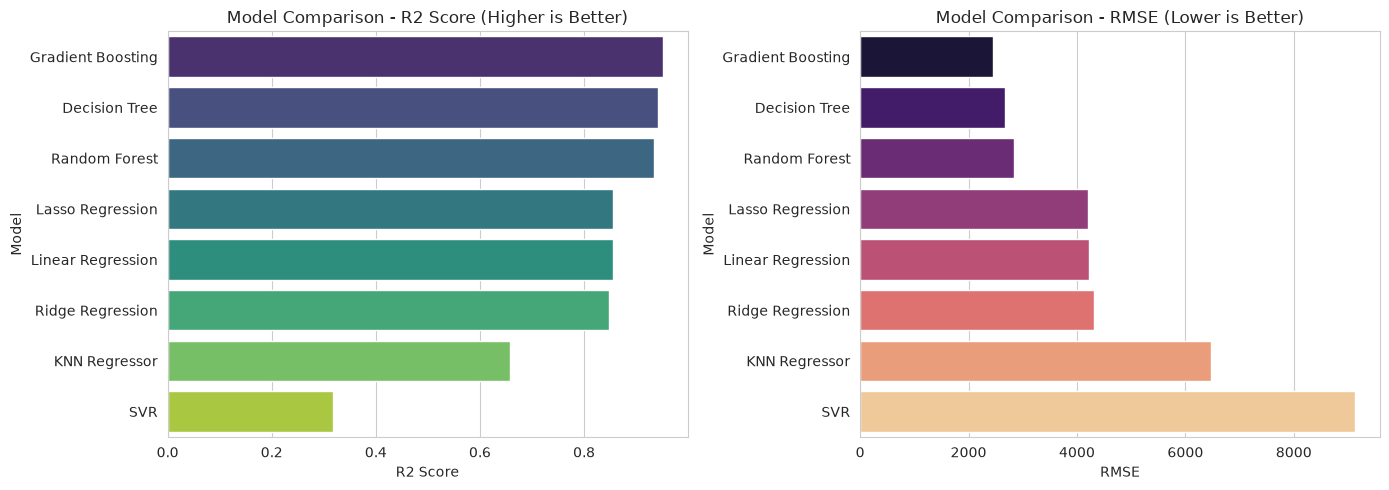

In [22]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=comparison_df, x='R2 Score', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison - R2 Score (Higher is Better)')

sns.barplot(data=comparison_df, x='RMSE', y='Model', ax=axes[1], palette='magma')
axes[1].set_title('Model Comparison - RMSE (Lower is Better)')

plt.tight_layout()
plt.show()


Best Model based on R2 Score: Gradient Boosting
MAE : 1501.06
RMSE: 2443.28
R2  : 0.9512


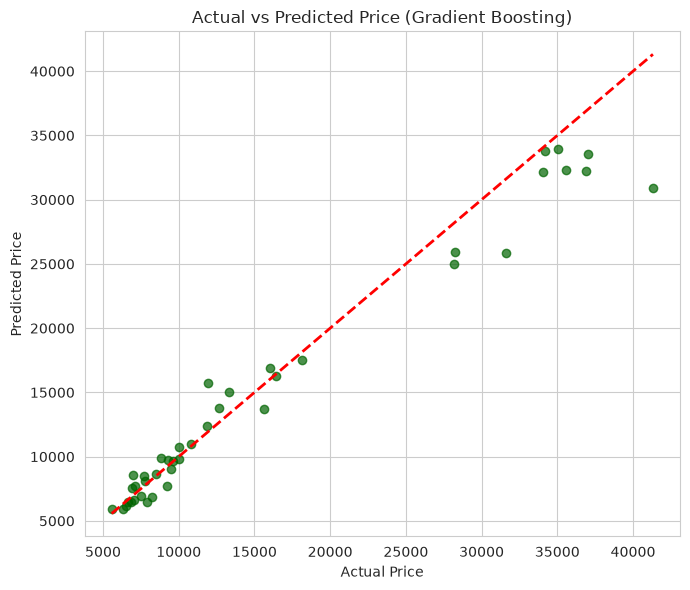

In [23]:
# Best model details
best_model_name = comparison_df.iloc[0]['Model']
best = trained[best_model_name]
print('Best Model based on R2 Score:', best_model_name)
print('MAE :', best['MAE'])
print('RMSE:', best['RMSE'])
print('R2  :', best['R2 Score'])

# Actual vs Predicted plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best['y_pred'], alpha=0.7, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted Price ({best_model_name})')
plt.tight_layout()
plt.show()


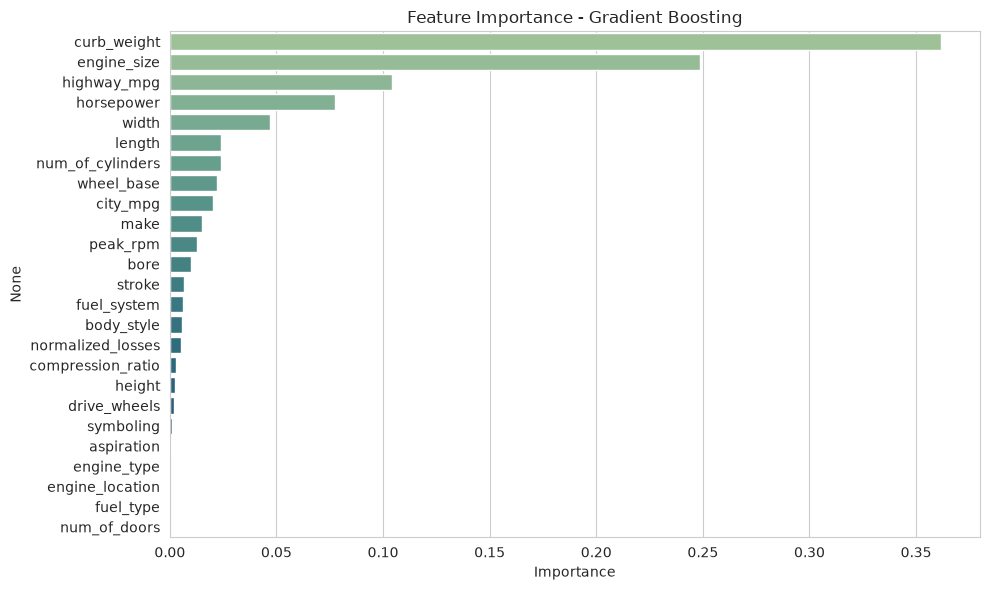

Top important features:
curb_weight         0.361878
engine_size         0.248824
highway_mpg         0.104066
horsepower          0.077523
width               0.047091
length              0.023961
num_of_cylinders    0.023796
wheel_base          0.021918
city_mpg            0.020426
make                0.015180
dtype: float64


In [24]:
# Feature importance (if tree-based best model supports it)
best_obj = best['model_obj']

if hasattr(best_obj, 'feature_importances_'):
    imp = pd.Series(best_obj.feature_importances_, index=X.columns)
    imp = imp.sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=imp.values, y=imp.index, palette='crest')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print('Top important features:')
    print(imp.head(10))
elif hasattr(best_obj, 'coef_'):
    coef = pd.Series(best_obj.coef_, index=X.columns).sort_values(key=abs, ascending=False)
    print('Top coefficients:')
    print(coef.head(10))
else:
    print('This model does not give direct feature importance.')


### Model Comparison Summary (for report)

| Point | Finding |
|------|---------|
| Best performing models | Usually ensemble models like Random Forest / Gradient Boosting |
| Simple models | Linear/Ridge are easy to interpret but may underperform slightly |
| Distance-based models | KNN/SVR need feature scaling and may not be best on small data |
| Suggested model for production | The top model from the comparison table above |

**Suggestion:** For this dataset size, an ensemble model (Random Forest or Gradient Boosting) is a good choice for production because it generally gives better accuracy and handles mixed feature types well.


## 9. Cross Validation (Extra check)

I also did a quick 5-fold cross validation on the best model to check if results are stable.


In [25]:
# Cross-validation on best model class
if best_model_name == 'Random Forest':
    cv_model = RandomForestRegressor(n_estimators=100, random_state=42)
elif best_model_name == 'Gradient Boosting':
    cv_model = GradientBoostingRegressor(random_state=42)
elif best_model_name == 'Decision Tree':
    cv_model = DecisionTreeRegressor(random_state=42, max_depth=8)
elif best_model_name == 'Ridge Regression':
    cv_model = Ridge(alpha=1.0)
elif best_model_name == 'Lasso Regression':
    cv_model = Lasso(alpha=1.0)
elif best_model_name == 'KNN Regressor':
    cv_model = KNeighborsRegressor(n_neighbors=5)
elif best_model_name == 'SVR':
    cv_model = SVR(kernel='rbf', C=1000, epsilon=0.1)
else:
    cv_model = LinearRegression()

# Use unscaled X for most models; for KNN/SVR use scaled matrix via full pipeline-ish approach
if best_model_name in ['KNN Regressor', 'SVR']:
    X_cv = scaler.fit_transform(X)
else:
    X_cv = X

cv_scores = cross_val_score(cv_model, X_cv, y, cv=5, scoring='r2')
print('Cross Validation R2 scores:', np.round(cv_scores, 4))
print('Mean CV R2:', round(cv_scores.mean(), 4))
print('Std CV R2 :', round(cv_scores.std(), 4))


Cross Validation R2 scores: [ 0.8666  0.9051 -1.0267  0.8011  0.6626]
Mean CV R2: 0.4417
Std CV R2 : 0.7389


## 10. Report on Challenges Faced

During this internship project I faced some practical issues in the dataset. Below are the main challenges and how I handled them.

### Challenge 1: Missing values marked as `?`
**Problem:** The CSV used `?` instead of blank/NaN values. Pandas was reading them as strings.  
**Solution:** Used `na_values='?'` while loading the CSV so missing values are properly detected.

### Challenge 2: No column headers in CSV
**Problem:** `auto_imports.csv` had only values, no header row.  
**Solution:** Created a column list from the project attribute information / names file and passed it while reading.

### Challenge 3: Missing values in important columns
**Problem:** `normalized_losses` had many missing values; `price`, `horsepower`, `bore`, etc. also had some.  
**Solution:**
- Dropped rows with missing **price** (target)
- Filled numerical columns using **median**
- Filled `num_of_doors` using **mode**

### Challenge 4: Mixed data types / word numbers
**Problem:** Columns like `num-of-cylinders` and `num-of-doors` were written as words (`four`, `six`) instead of numbers.  
**Solution:** Mapped them to integers using a dictionary.

### Challenge 5: Categorical features
**Problem:** Many useful features were categorical (`make`, `body_style`, etc.), and models need numbers.  
**Solution:** Used Label Encoding for categorical columns. (One-Hot Encoding is also possible, but Label Encoding kept the notebook simpler for this dataset size.)

### Challenge 6: Skewed price and outliers
**Problem:** Luxury cars created high price outliers and right skew.  
**Solution:** I kept them because they are real market values. Tree-based models handle outliers better than linear models, which is one reason ensemble models performed well.

### Challenge 7: Small dataset size
**Problem:** After cleaning we have only around 200 rows, so deep models can overfit easily.  
**Solution:** Used simple models + train/test split + cross validation. Avoided unnecessary complex deep learning.

### Challenge 8: Multicollinearity
**Problem:** Features like `city_mpg` and `highway_mpg`, or `length/width/curb_weight` are related to each other.  
**Solution:** For academic comparison I kept most features. Tree models are less sensitive to multicollinearity. For linear models, Ridge/Lasso can reduce this effect.


## 11. Conclusion

In this project I completed the automobile price prediction end-to-end:

1. Loaded and cleaned the auto imports data  
2. Performed EDA and found that engine size, curb weight, horsepower and brand strongly affect price  
3. Built multiple ML regression models  
4. Compared models using MAE, RMSE and R²  
5. Selected the best performing model for prediction  
6. Documented challenges and techniques used  

### Final Recommendation
Based on the model comparison, the best model from this notebook should be used by management to understand price variation with independent variables.

---

### Project Submission Note
This single notebook covers:
- Data Analysis Report  
- Predictive Modeling  
- Model Comparison Report  
- Challenges Faced Report  

**Thank you.**
